# 1. 观察 & 抽象规则$R$制定 

## 1.1. 观察特性

以epoch=10为例，观察各个样本（红色为异常，蓝色为正常）的损失值随迭代的变化情况，选出经典的情况代表如下：

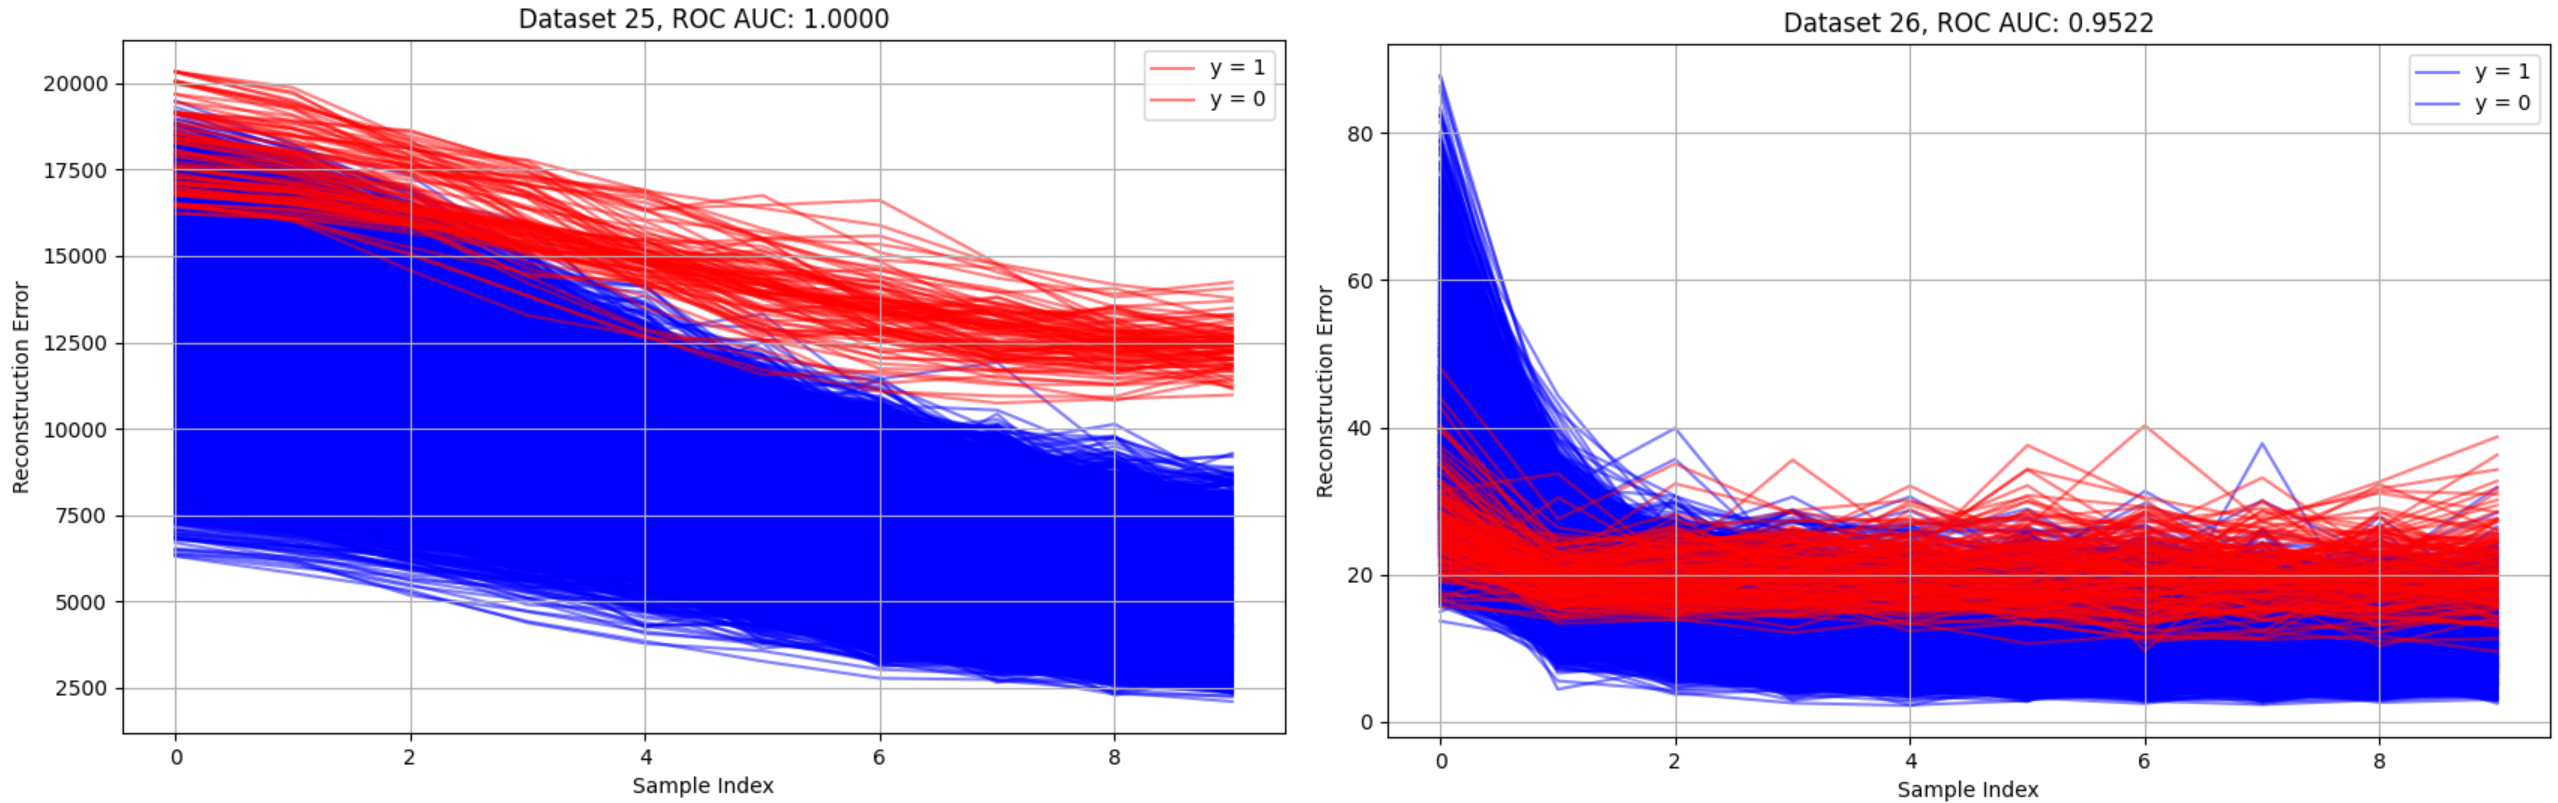


观察得良好情况下，正常样本区别于异常样本的损失变化主要有两方面：

1. **幅度区别**：下降幅度相对更大（能够更快地收敛到较低的损失值）
2. **最值区别**：最终的损失值相对更低（正常样本的重构损失更小）

然而正常样本的下降曲线（蓝色）在不同数据有所异同，有些是开始就快速下降（右图），有的需要长期的迭代才能下降（左图）


### 1.1.1. 困难点

有些数据集有明显的异常嵌入，难以分辨：
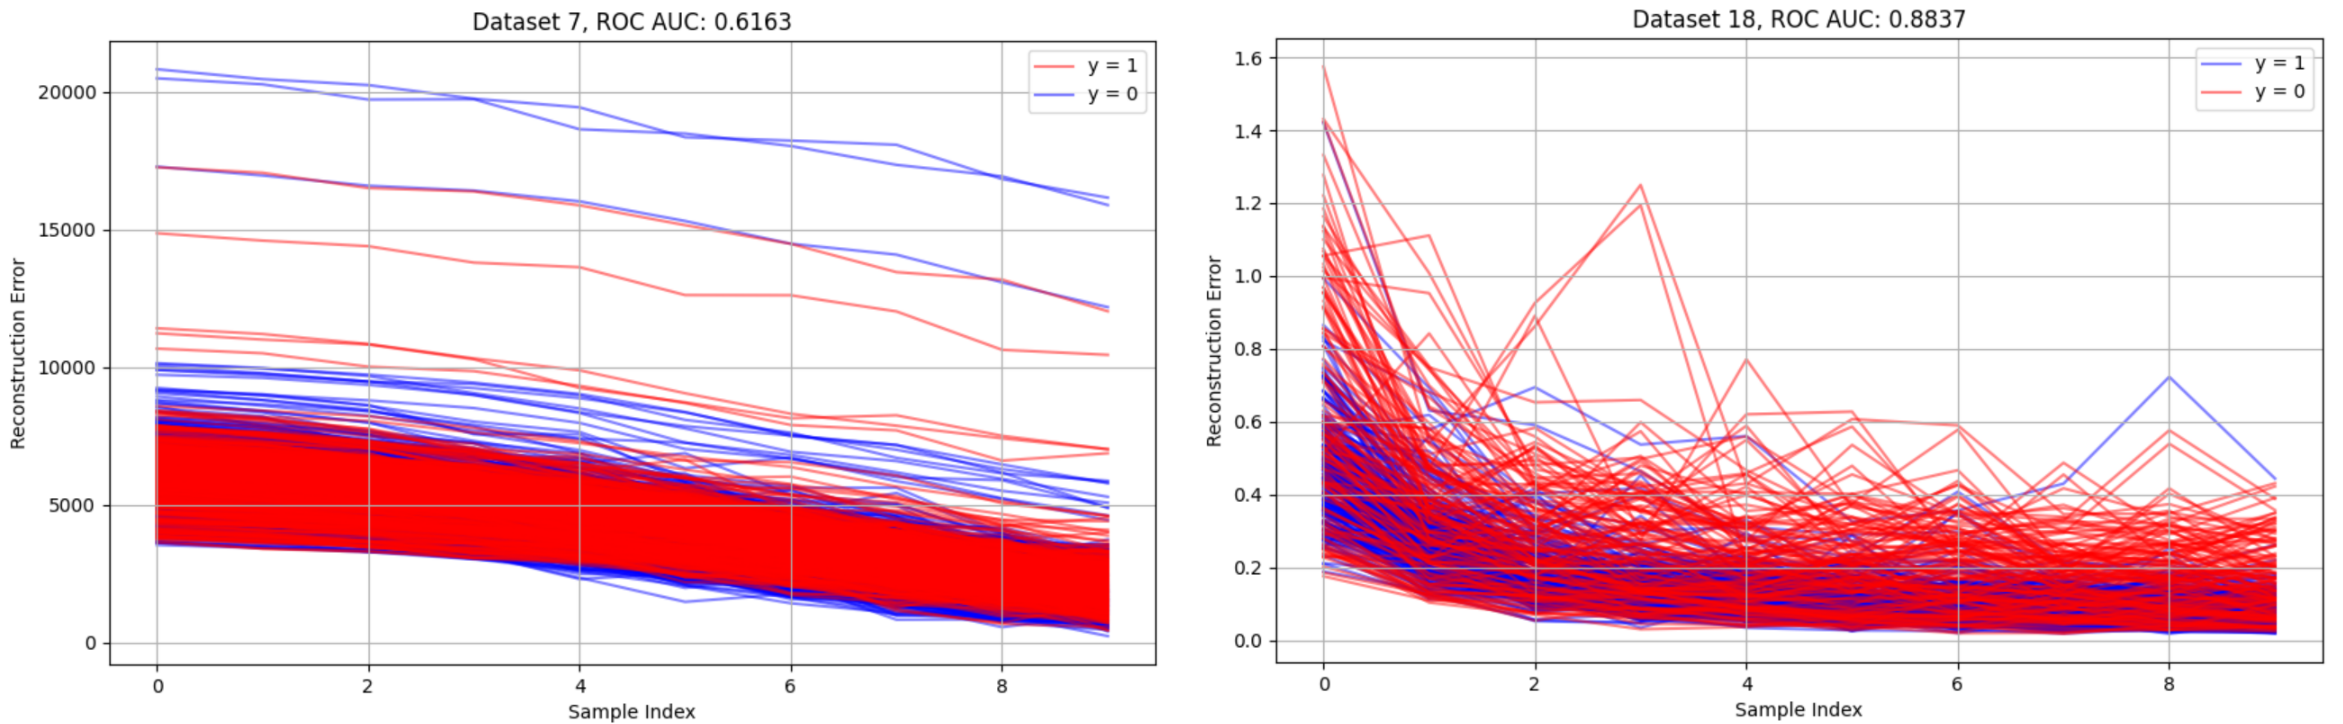



## 1.2. 抽象规则$R$制定

若以前述两个特性为基础，我们可以制定规则$R$，以便于每次迭代后，可以根据损失值的变化情况（随着参数更新，各个样本的loss下降曲线），选出部分辨识度较高的样本作为伪标签（或用于微调），从而进行后续模型的构建。

基于样本损失从$l_{AE}^{(t)}$到$l_{AE}^{(t+1)}$的下降曲线，制定关于正常、异常样本集合$P$、$N$的分割规则$R^{(t)}$，用于将$X$中部分新的元素添加到正常集$P$和异常集$N$中，从而更新两个集合，即：
$$
P^{(t+1)},N^{(t+1)} \xleftarrow{\ R^{(t)}\ } P^{(t)},N^{(t)}
$$




**现在先假设这个规则$R$是已知的，我想先确认后面的模型构建流程是否正确**：

# 2. AE&SVM 思路

## 2.1. 流程

1. **训练AutoEncoder**：使用正常样本训练AutoEncoder，得到重构误差曲线，根据规则$R$，选出部分正常、异常样本$P$、$N$作为伪标签
2. **训练SVM**：使用$P$、$N$训练SVM，得到分类器$f_{SVM}$
3. **分配伪标签**：使用$f_{SVM}$对所有未标签样本分类，得到标签结果

## 2.2. 实操过程中的问题和发现

以前面第一张图片的Dataset 25为例，确实做到了用少量标签进行SVM分类就能达到1.0的准确率，但是我对于其他数据试验后发现，这种方法的问题有：

1. **标签敏感**：通过 Dataset 25 和Dataset 26的实验发现，如果伪标签选取时本身就是错的，会导致两者结合的准确率直接大幅度下降
2. **标签数与准确率的权衡**：在选取阈值的时候，如果增加标签样本数，会导致准确率下降，但是如果减少标签样本数，会导致准确率下降，而且这是一个无监督学习的过程，无法知道根据标签后的准确率，以及要能选多少的已标签样本数
3. **调参发现**：发现选择多一些正常伪标签和少一些的异常伪标签，能一定程度上提高准确率

# 3. AE-CL思路

对于$n×d$的数据集$X=\{\mathbf{x}_1,\mathbf{x}_2,...,\mathbf{x}_n\}$，其中$x_i\in \mathbb{R}^d$，设在权重网络(微调后)的第$t$次迭代后($t=1,2,\dots,T$)，网络参数为$W^{(t)}$，对应每个样本的重构损失：

$$
l_{AE}^{(t)}(\mathbf{x}_i)=\|\mathbf{x}_i-f_W^{(t)}(\mathbf{x}_i)\|_2 \tag{3-1}
$$

其中$f_W^{(t)}$为网络参数为$W^{(t)}$时自编码器对$\mathbf{x}$的重构映射

$t=0$时，

- 初始化$w$均为1

- 设认定的正常集和异常集分别为$P$和$N$，初始化为空集；

- $W$初始化为微调后的网络参数

从$t=0$开始，执行以下步骤：

## 3.1. 步骤一：

更新一次网络参数$W^{(t+1)}$：
$$
W^{(t+1)}\leftarrow W^{(t)} \text{ by } \min \sum_{i=1}^n w_{i}^{(t)}· l_{AE}^{(t)}(\mathbf{x}_i) 
\tag{3-2}
$$

更新后重新计算各个样本的损失：


$$
l_{AE}^{(t+1)}(\mathbf{x}_i)=\|\mathbf{x}_i-f_W^{(t+1)}(\mathbf{x}_i)\|_2 \tag{3-3}
$$


## 3.2. 步骤二：

基于样本损失从$l_{AE}^{(t)}$到$l_{AE}^{(t+1)}$的下降曲线，制定关于正常样本、异常样本的分割规则$R^{(t)}$，用于将部分新的元素添加到正常集$P$和异常集$N$中，即：
$$
P^{(t+1)},N^{(t+1)} \xleftarrow{\ R^{(t)}\ } P^{(t)},N^{(t)} \tag{3-4}
$$

## 3.3. 步骤三：

通过用正类样本微调更新网络权重：
$$
W^{(t+1)}\leftarrow  W^{(t+1)} \text{ by } \min l_{AE}^{(t+1)}(P^{(t+1)}) 
\tag{3-2}
$$


## 3.4. 步骤四：
更新损失函数的权重：
$$
w_i^{(t+1)} = \begin{cases} 
1,\quad \mathbf{x}_i\in P^{(t)} \\
0, \quad \mathbf{x}_i\in N^{(t)}\\
\mathcal{N}_{\text{min-max}}( \|\mathbf{x}_i-f^{(t+1)}_W(\mathbf{x}_i)\|_2), \quad \text{else}
\end{cases} 
\tag{3-6}
$$

## 3.5. 步骤五：

检查是否满足停止条件，若未则$t$加1，重新步骤一继续执行